In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv(r"C:\Users\Top Prix\OneDrive\New folder\Thesis_Project\data\processed_data\processed_rin_data.csv")
df.head()
df.columns = ['timestamp','load']


In [5]:
import matplotlib.pyplot as plt

In [2]:
df.set_index('timestamp', inplace=True)
df.index = pd.to_datetime(df.index)


In [3]:
df.columns

Index(['load'], dtype='object')

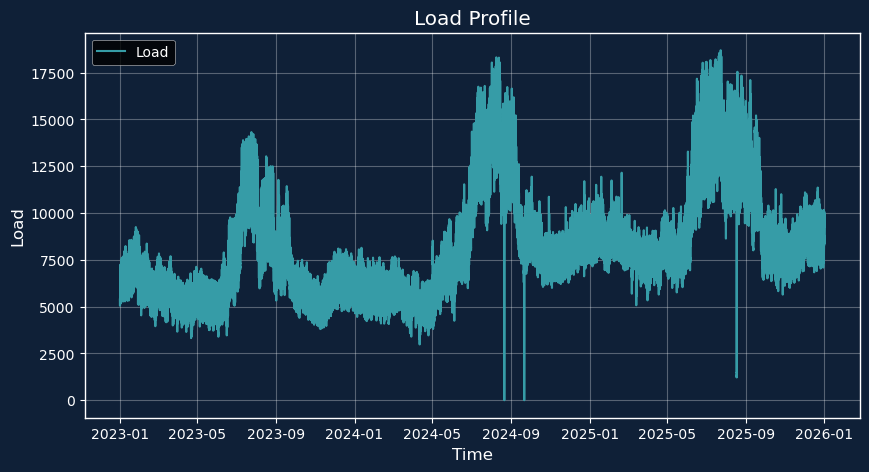

In [ ]:
BG = "#0f2037"   # dark navy — tweak to taste
FG = "white"

fig, ax = plt.subplots(figsize=(10, 5))

ax.set_facecolor(BG)
fig.patch.set_facecolor(BG)


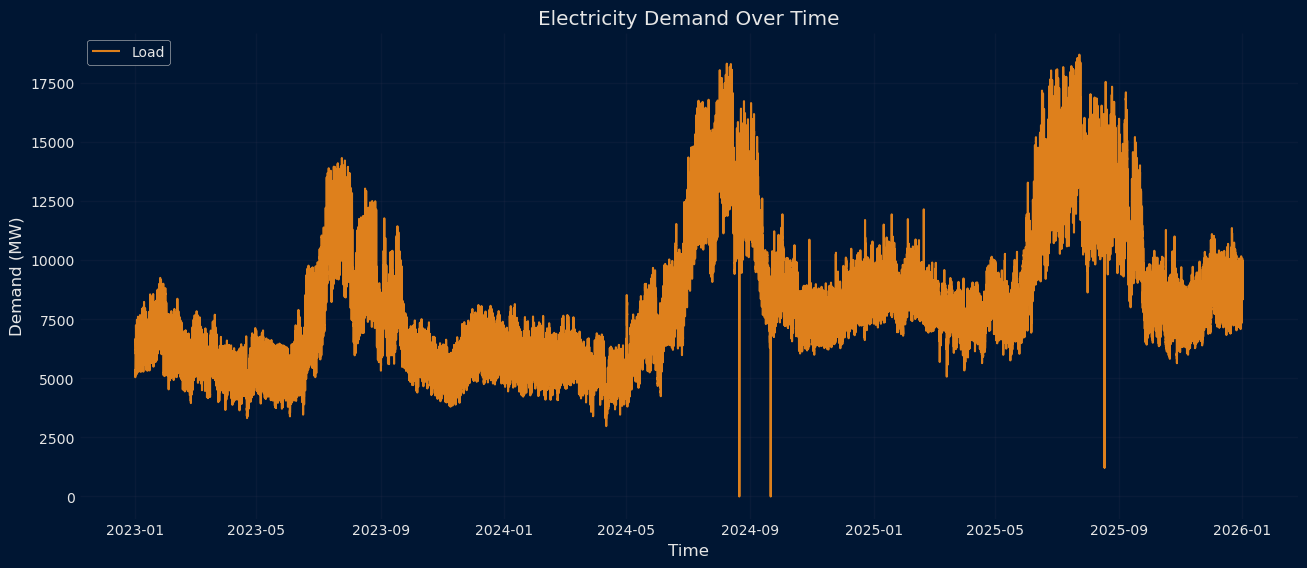

In [46]:
from skforecast.plot import set_dark_theme
set_dark_theme() 
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['load'], label='Load', color="#DE801C")
plt.grid(alpha=0.3)
plt.xlabel('Time')
plt.ylabel('Demand (MW)')
plt.title('Electricity Demand Over Time')
plt.legend(loc='upper left')
plt.show()

NameError: name 'train' is not defined

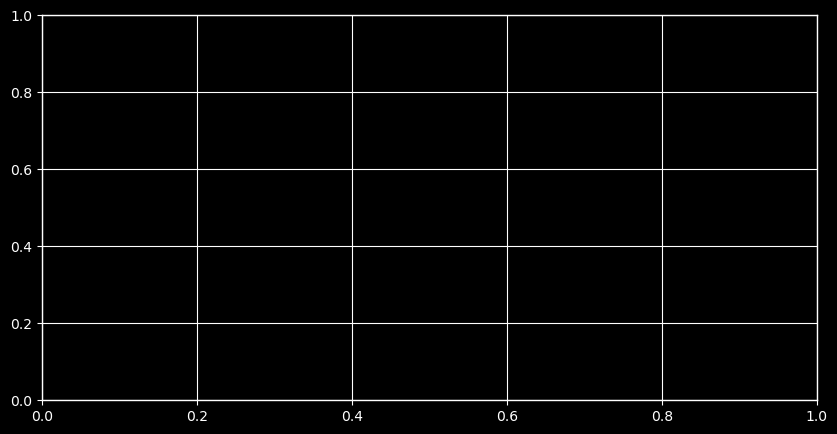

In [24]:
import matplotlib.pyplot as plt

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(train.index, train["load"], color="#5bc8f5", linewidth=1, label="train")
ax.plot(test.index, test["load"],  color="#f56b5b", linewidth=1, label="test")

ax.set_facecolor("#1a1f2e")
fig.patch.set_facecolor("#1a1f2e")

ax.set_title("Hourly load consumption - RIN", color="white", fontsize=13)
ax.set_xlabel("date", color="white")
ax.tick_params(colors="white")
ax.legend(facecolor="#2a2f3e", edgecolor="none", labelcolor="white")

# subtle grid
ax.grid(True, color="white", alpha=0.1, linewidth=0.5)

plt.tight_layout()
plt.savefig("load_plot.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

In [3]:
df[df['load']<2000]

,load
timestamp,
2024-08-21 00:45:00,0.000000
2024-09-21 00:45:00,0.000000
2025-08-17 06:00:00,1297.000000
2025-08-17 06:15:00,1327.000000
2025-08-17 06:30:00,1247.000000
2025-08-17 06:45:00,1302.000000
2025-08-17 07:00:00,1337.000000
2025-08-17 07:15:00,1297.000000
2025-08-17 07:30:00,1247.000000


In [4]:
Q1 = df['load'].quantile(0.25)
Q3 = df['load'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
outliers = df[df['load'] < lower_bound]

In [5]:
outliers.head()

,load
timestamp,
2024-08-21 00:45:00,0.0
2024-09-21 00:45:00,0.0


In [9]:
df.drop(df[df['load'] == 0].index, inplace=True)

In [13]:
df = df.resample('15T').mean()


C:\Users\Top Prix\AppData\Local\Temp\ipykernel_20540\3336767325.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.resample('15T').mean()


In [48]:
df.loc[df['load'] == 0, 'load'] = np.nan

# Example: remove abnormal low values (you can adjust threshold)
threshold = 2000
df.loc[df['load'] < threshold, 'load'] = np.nan

# Interpolate missing values
df['load'] = df['load'].interpolate(method='linear')


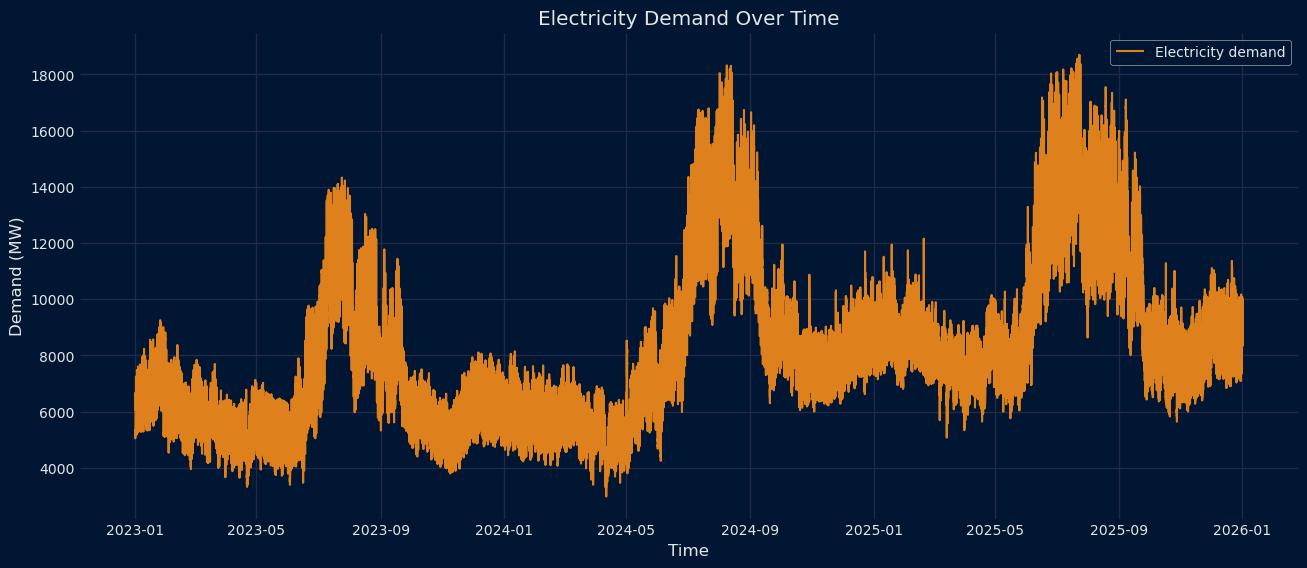

In [ ]:
from skforecast.plot import set_dark_theme
set_dark_theme() 
plt.figure(figsize=(14,6))
plt.plot(df.index, df['load'], label='Electricity demand', color="#DE801C")
plt.title('Electricity Demand Over Time')
plt.xlabel('Time')
plt.ylabel('Demand (MW)')
plt.legend()
plt.show()

In [50]:




import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import (
    load_data,
    regularize_time_index,
    detect_and_fix_anomalies,
    aggregate_hourly
)

# Load
df = load_data(r"C:\Users\Top Prix\OneDrive\New folder\Thesis_Project\data\processed_data\processed_rin_data.csv")

# Regularize
df = regularize_time_index(df)

# Clean
df = detect_and_fix_anomalies(df)

# Aggregate
df_hourly = aggregate_hourly(df)

print(df_hourly.head())
print(df_hourly.isna().sum())

                            load
timestamp                       
2023-01-01 00:00:00  5317.916667
2023-01-01 01:00:00  5271.333333
2023-01-01 02:00:00  5142.833333
2023-01-01 03:00:00  5110.250000
2023-01-01 04:00:00  5126.833333
load    0
dtype: int64


c:\Users\Top Prix\OneDrive\New folder\Thesis_Project\src\preprocessing.py:20: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.resample('15T').mean()
c:\Users\Top Prix\OneDrive\New folder\Thesis_Project\src\preprocessing.py:39: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


In [ ]:
df_hourly.

,load
count,26304.000000
mean,8227.460172
std,2817.568235
min,3084.000000
25%,6156.687500
50%,7664.875000
75%,9451.937500
max,18566.658854


In [3]:
df_hourly.index.min(), df_hourly.index.max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2025-12-31 23:00:00'))

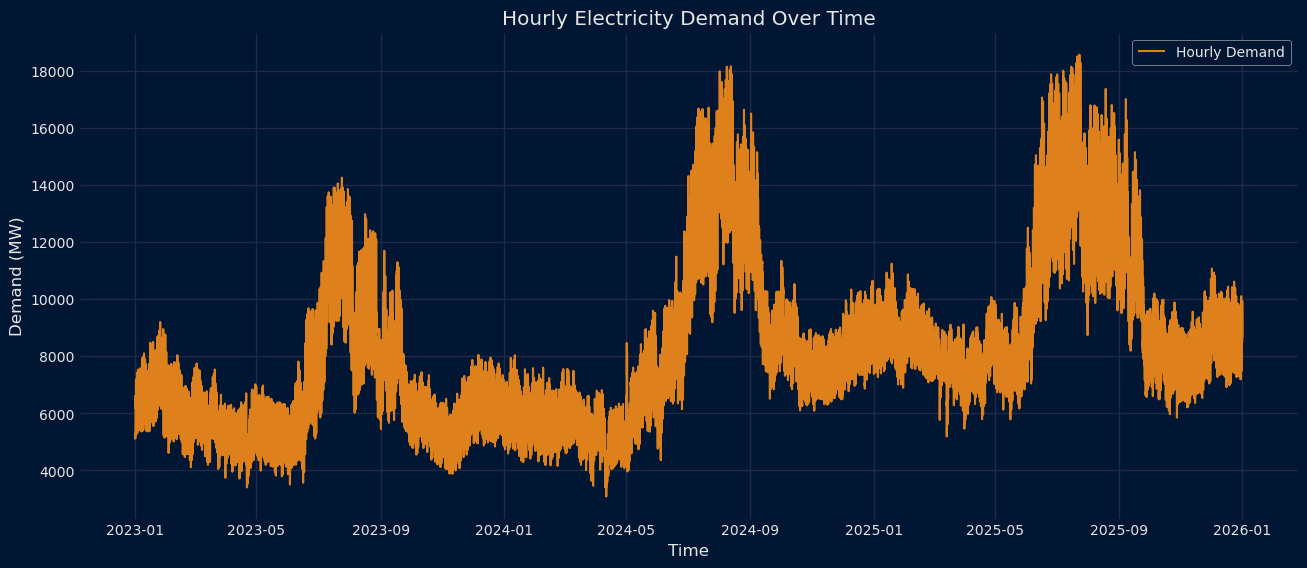

In [51]:
set_dark_theme() 
plt.figure(figsize=(14,6))
plt.plot(df_hourly.index, df_hourly['load'], label='Hourly Demand', color="#DE801C")
plt.title('Hourly Electricity Demand Over Time')
plt.xlabel('Time')
plt.ylabel('Demand (MW)')
plt.legend()
plt.show()

In [3]:
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek
df_hourly['month'] = df_hourly.index.month
df_hourly['year'] = df_hourly.index.year

In [4]:
df_hourly.head()

,load,hour,day_of_week,month,year
timestamp,,,,,
2023-01-01 00:00:00,5317.916667,0,6,1,2023
2023-01-01 01:00:00,5271.333333,1,6,1,2023
2023-01-01 02:00:00,5142.833333,2,6,1,2023
2023-01-01 03:00:00,5110.250000,3,6,1,2023
2023-01-01 04:00:00,5126.833333,4,6,1,2023


In [6]:
df_hourly.to_csv("enriched_data.csv")